# TWII Next-Day Return Forecasting — ABLATION: no feature selection

**Experiment variant.** Identical to `run_pipeline.ipynb` in every respect except
one: the train-only **temporal-consistency feature selection is disabled**, so the
LightGBM regressor is handed **all** engineered features (including the
non-stationary price-level ones — MAs, EMAs, Bollinger bands, MACD — that the main
pipeline drops). Everything else (data, split, scaling, tuning, evaluation, SHAP,
plots) is unchanged, so the two notebooks are directly comparable.

> **Honest scope.** Out-of-sample R² on daily returns is expected ≈ 0 or negative;
> 51–54% directional accuracy is a *good* result. Every metric sits next to a baseline.

This notebook is deliberately thin: all logic lives in `src/twii_forecast/`; here we
just call `pipeline.run(..., select_features=False)` and render.

In [1]:
import sys, pathlib
# make src/ importable regardless of where the kernel is launched
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "twii_forecast").exists():
        sys.path.insert(0, str(_p / "src")); break

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s | %(message)s", stream=sys.stdout)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

import pandas as pd
from IPython.display import Image, display

from twii_forecast import pipeline, plots, explain, evaluate, config

## 1–8. Run the end-to-end pipeline (no feature selection)
Data → features/target/dataset → **(temporal-consistency selection SKIPPED — all features kept)** → chronological 85/5/10 split → RobustScaler (fit on train) → LightGBM random-search + early stopping → per-next-day evaluation → SHAP.

In [2]:
r = pipeline.run(n_iter=config.N_RANDOM_SEARCH, tune=True, select_features=False)
print("\nsplit:", r["split"].describe())
print("volume gate passed:", r["volume_ok"])
print("features used (no selection):", len(r["kept_features"]), "/", len(r["feature_cols"]))
print("train-vs-test drift report:", r["drift_report"])

INFO twii_forecast.data | loaded cached raw data: 5241 rows
INFO twii_forecast.data | volume gate: zero=0.002 nan=0.000 degenerate=0.002 threshold=0.050
INFO twii_forecast.dataset | dataset: 5241 rows -> 5181 after dropping warmup/tail NaNs (36 features)
INFO twii_forecast.split | split: train 2005-04-06..2023-03-20 (n=4403) | val 2023-03-21..2024-04-15 (n=259) | test 2024-04-16..2026-06-04 (n=519)
INFO twii_forecast.pipeline | feature selection disabled: keeping all 36 features
INFO twii_forecast.monitor | wrote drift report -> /Users/wanchuan/quant-demo/reports/drift_report.html


random search: 100%|██████████| 40/40 [00:07<00:00,  5.47it/s]

INFO twii_forecast.model | best val MAE=5.738697e-03 with params={'num_leaves': 58, 'learning_rate': 0.05565032216989928, 'max_depth': 12, 'min_child_samples': 57, 'feature_fraction': 0.8923817246260937, 'bagging_fraction': 0.5089183919884939, 'lambda_l1': 0.00035133384110443714, 'lambda_l2': 1.4032759250616358}


INFO twii_forecast.model | refit best_iteration=44
INFO twii_forecast.model | saved model -> /Users/wanchuan/quant-demo/data/processed/lgbm_model.txt, params -> /Users/wanchuan/quant-demo/data/processed/best_params.json

split: train 2005-04-06..2023-03-20 (n=4403) | val 2023-03-21..2024-04-15 (n=259) | test 2024-04-16..2026-06-04 (n=519)
volume gate passed: True
features used (no selection): 36 / 36
train-vs-test drift report: /Users/wanchuan/quant-demo/reports/drift_report.html


## Temporal consistency analysis — DISABLED for this experiment
This variant intentionally **skips** the temporal-consistency feature selection, so
there is no AUC table and no features are dropped: the model trains on the full
feature set. The cell below confirms all features are passed through.

In [3]:
assert r["auc_table"] is None, "expected no AUC table when select_features=False"
print(f"feature selection disabled — all {len(r['kept_features'])} features kept:")
print(r["kept_features"])

feature selection disabled — all 36 features kept:
['amplitude', 'difference', 'h_minus_l', 'c_minus_o', 'delta_c', 'daily_return', 'momentum', 'sign_delta_open', 'intraday_ma_5', 'delta_c_ma_5', 'intraday_ma_10', 'delta_c_ma_10', 'intraday_ma_20', 'delta_c_ma_20', 'ma_5', 'ema_5', 'ma_10', 'ema_10', 'ma_20', 'ema_20', 'ma_60', 'ema_60', 'macd', 'rsi', 'williams_r', 'bb_high', 'bb_low', 'ret_lag_0', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_5', 'delta_v', 'delta_v_ma_5', 'delta_v_ma_10', 'delta_v_ma_20']


## 6. Evaluation — per next-day prediction, vs. baselines

The headline is **directional accuracy**. Baselines: *persistence* (r̂ = 0) and
*historical mean* (r̂ = mean train return). The historical-mean baseline is the
meaningful directional yardstick (persistence has sign 0, so its DirAcc is 0 by
construction).

In [4]:
print(evaluate.format_table(r["metrics_table"]))

                            mae          rmse  dir_acc       ic       r2
model              1.093015e-02  1.563210e-02  +0.5453  +0.0214  -0.0048
persistence (r=0)  1.099182e-02  1.567383e-02  +0.0000     +nan  -0.0102
historical_mean    1.096431e-02  1.565367e-02  +0.5684  +0.0000  -0.0076


In [5]:
m = r["metrics_table"].loc["model"]; b = r["metrics_table"].loc["historical_mean"]
print(f"Model MAE {m.mae:.3e} vs persistence {r['metrics_table'].loc['persistence (r=0)','mae']:.3e}")
print(f"Model DirAcc {m.dir_acc:+.4f} vs always-up (historical mean) {b.dir_acc:+.4f}")
print(f"IC {m.ic:+.4f}  |  out-of-sample R² {m.r2:+.4f}  (≈0 or negative is expected & honest)")

Model MAE 1.093e-02 vs persistence 1.099e-02
Model DirAcc +0.5453 vs always-up (historical mean) +0.5684
IC +0.0214  |  out-of-sample R² -0.0048  (≈0 or negative is expected & honest)


## 7. SHAP feature importance (TreeSHAP)
Global importance over the test matrix. The paper found `difference` / `c_minus_o` (both from Cₜ−Oₜ) dominated — we check whether that holds for next-day *return* prediction here.

,feature,mean_abs_shap
0,delta_v_ma_5,0.000345
1,delta_c_ma_5,0.000308
2,intraday_ma_20,0.000280
3,c_minus_o,0.000225
4,h_minus_l,0.000205
5,intraday_ma_10,0.000201
6,ret_lag_3,0.000188
7,delta_c,0.000187
8,delta_c_ma_20,0.000185
9,ret_lag_5,0.000172


INFO twii_forecast.explain | saved SHAP plots: {'beeswarm': '/Users/wanchuan/quant-demo/reports/shap_beeswarm.png', 'bar': '/Users/wanchuan/quant-demo/reports/shap_bar.png'}


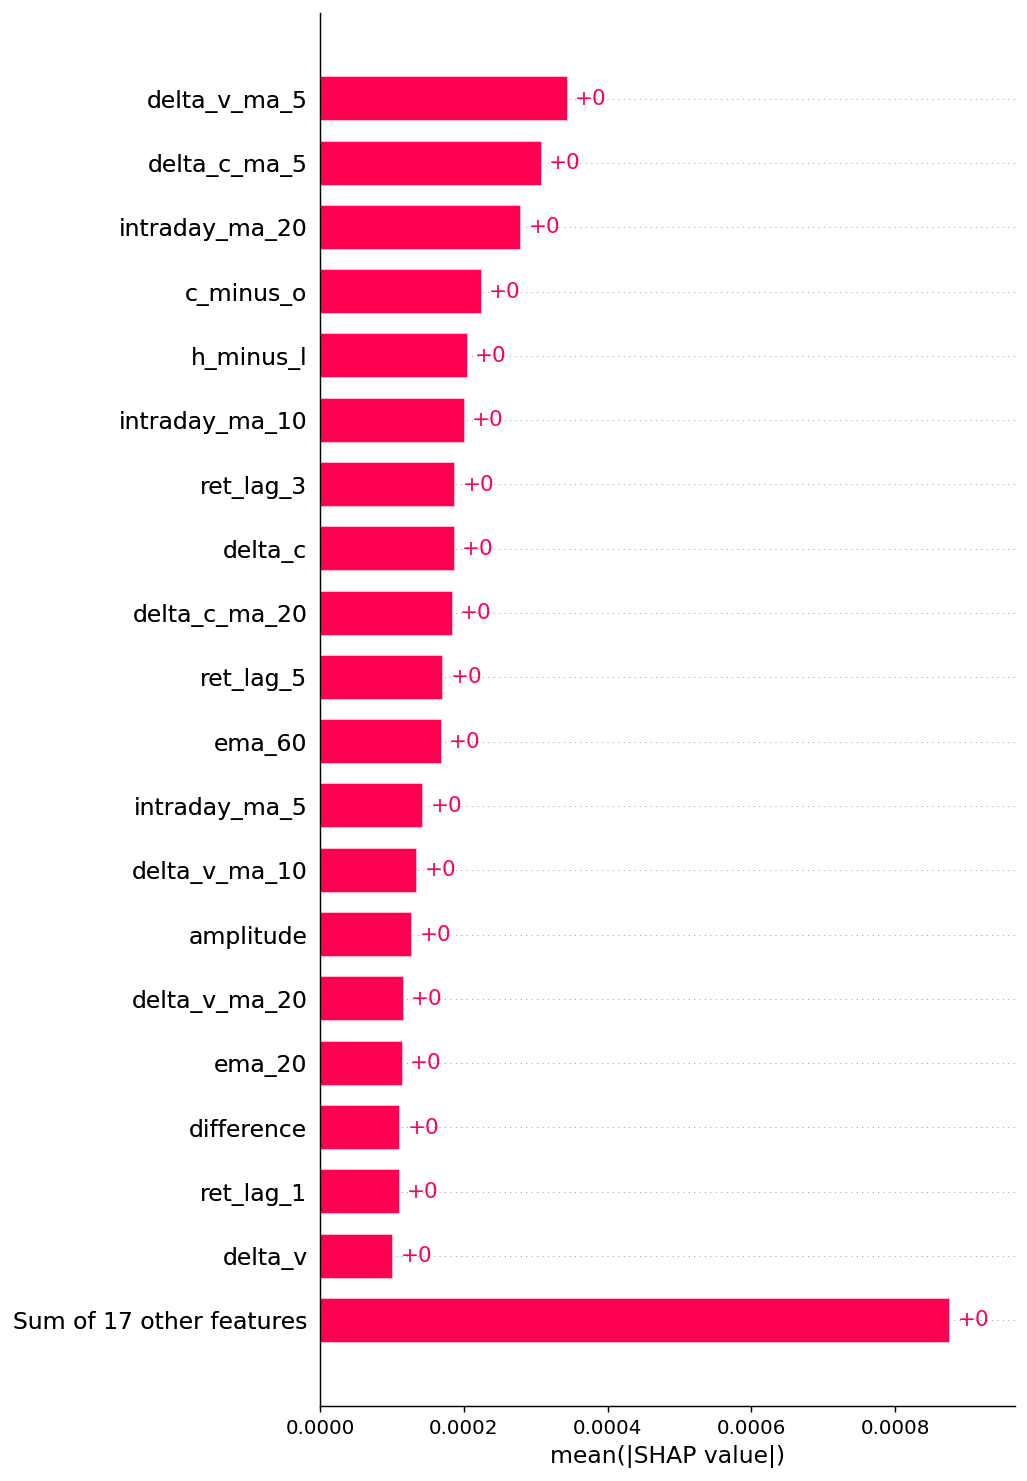

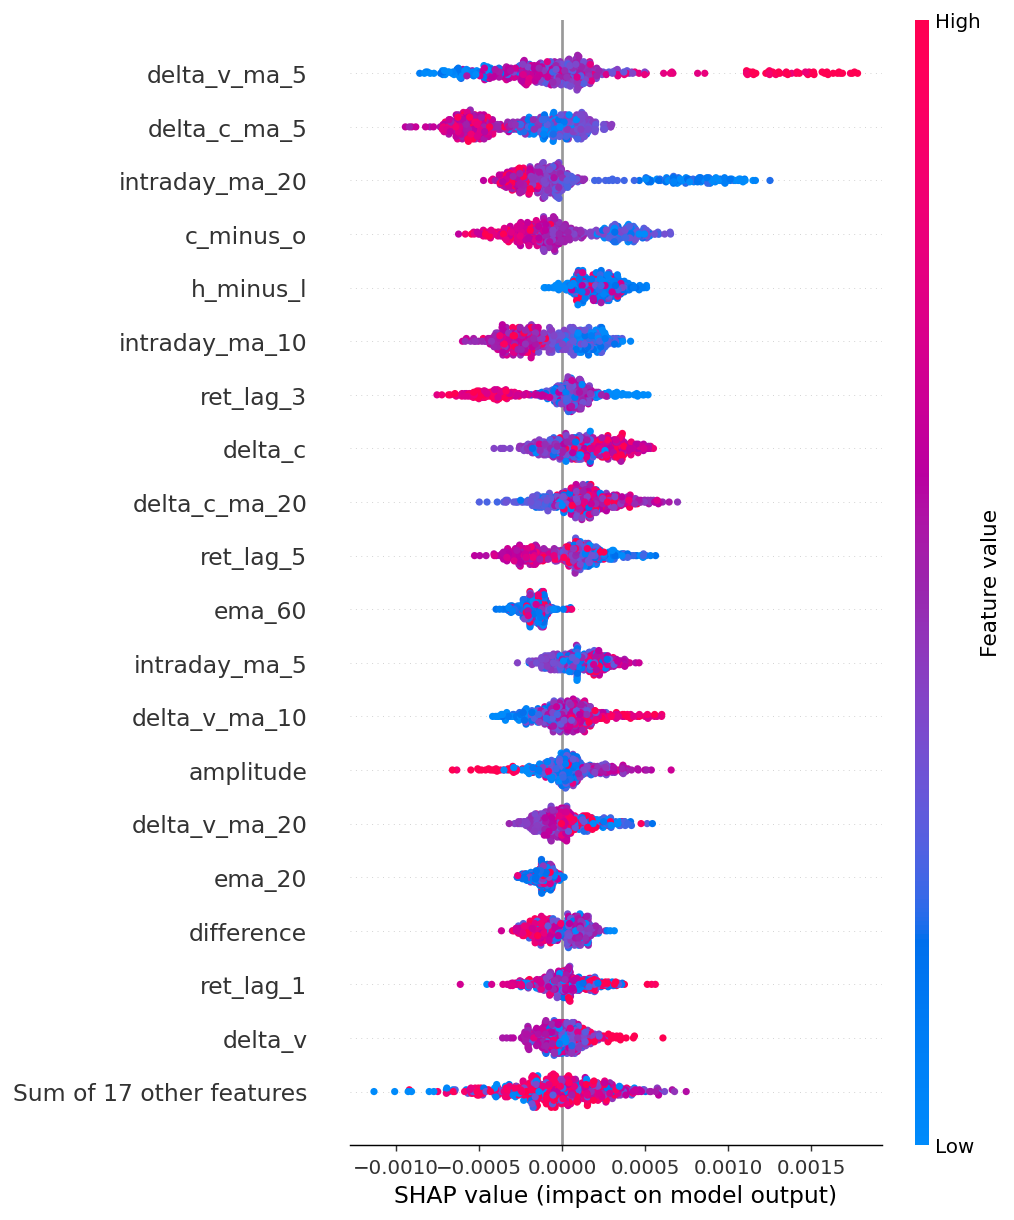

In [6]:
display(r["importance"].head(15))
paths = explain.save_plots(r["shap_values"])
display(Image(paths["bar"])); display(Image(paths["beeswarm"]))

## 12. Diagnostic plots
Candles of the test window, the per-prediction scatter (IC annotated), the residual histogram, and a **sanity-only** compounded path (explicitly excluded from the reported metrics).

INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/test_candles.png
INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/pred_vs_actual.png
INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/residuals.png
INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/compounded_sanity.png


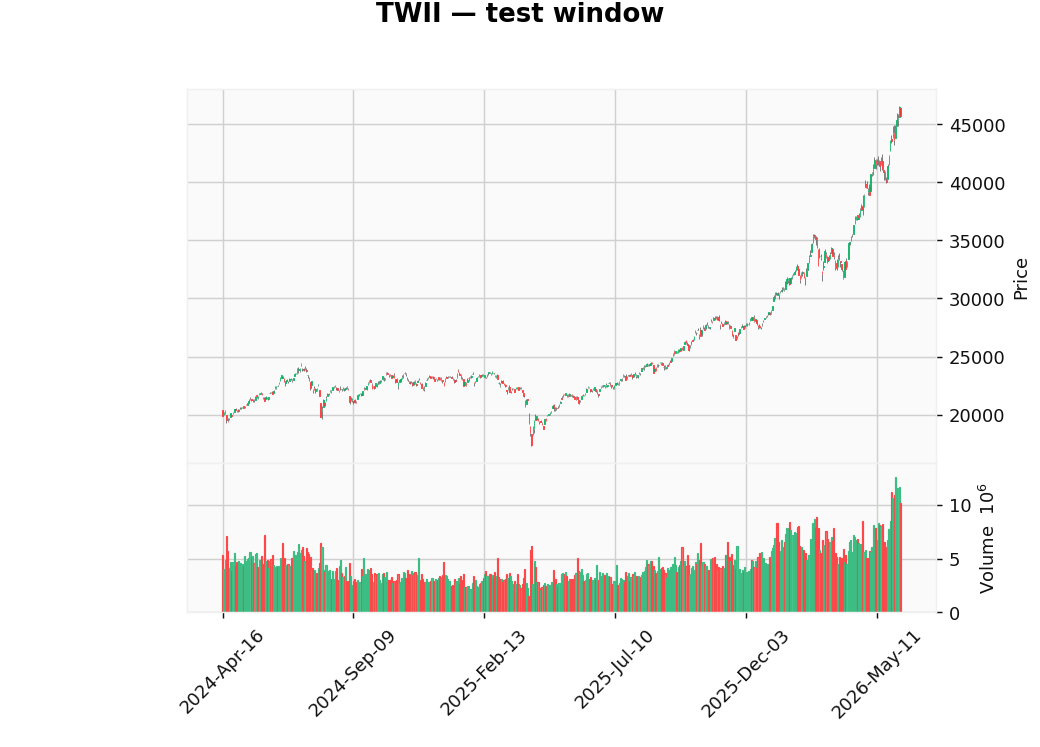

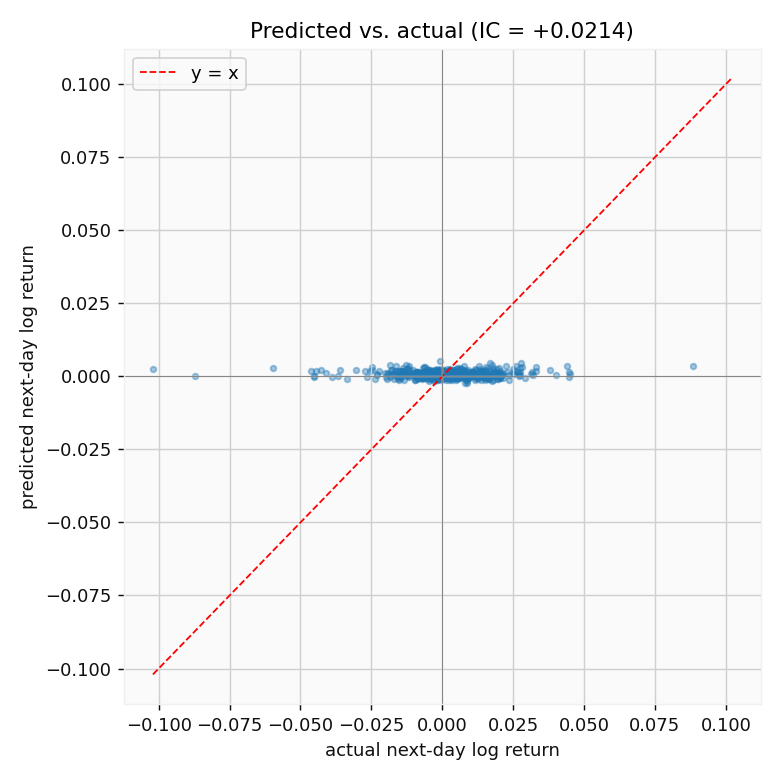

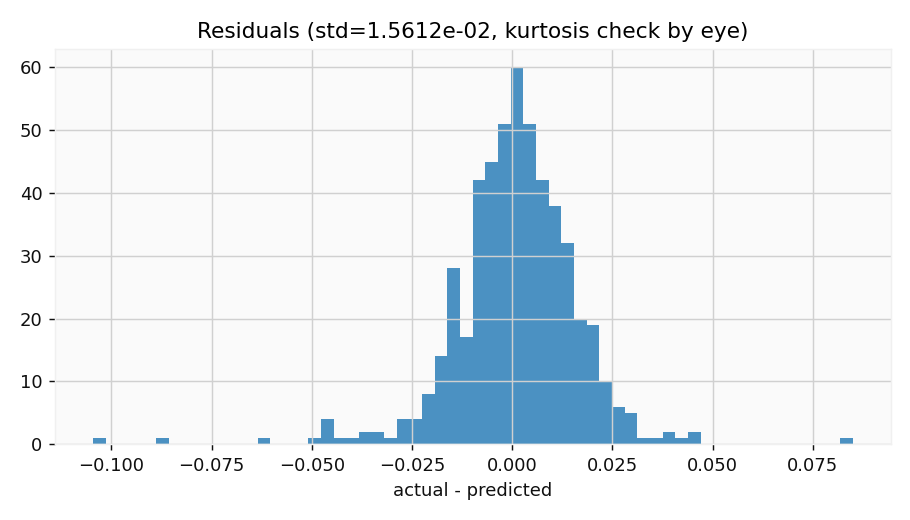

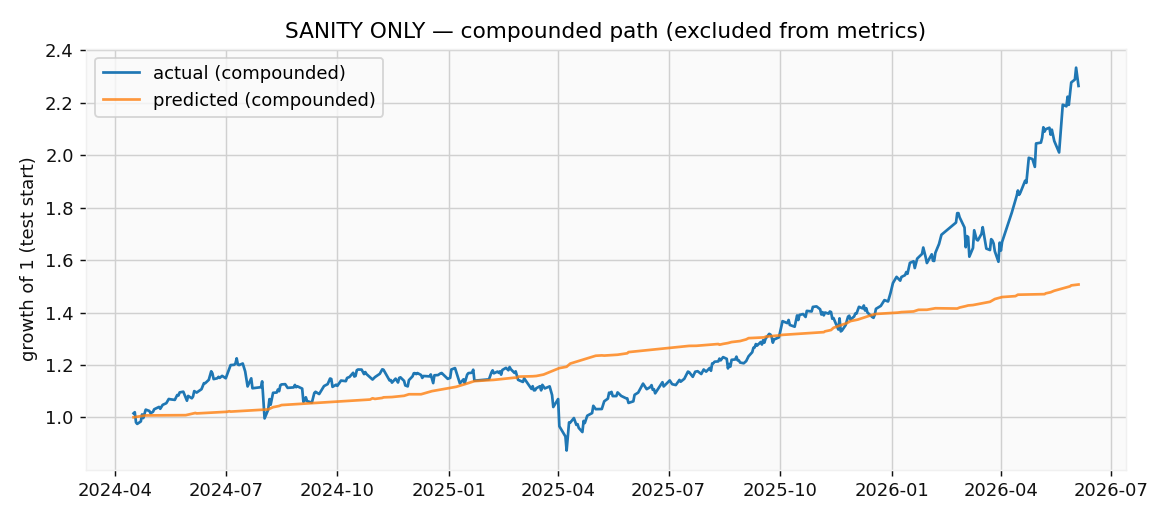

In [7]:
sp = r["split"]
cands = plots.candles(r["df_ohlcv"].loc[sp.test.index])
ic = r["metrics_table"].loc["model", "ic"]
pva = plots.pred_vs_actual(r["y_test"].values, r["y_pred"].values, ic)
res = plots.residual_hist(r["y_test"].values, r["y_pred"].values)
comp = plots.compounded_sanity(r["y_test"].index, r["y_test"].values, r["y_pred"].values)
for p in (cands, pva, res, comp):
    display(Image(p))

## Directional analysis — binary confusion matrix + per-day actual vs. predicted

The directional call as a 2x2 **up/down confusion matrix** (flat-actual days excluded,
consistent with the reported DirAcc), followed by a **per-day** view over the test
window with predicted markers coloured by directional hit (green) or miss (red).

Read it together with the earlier diagnosis: the model shrinks predictions toward the
conditional median, so it predicts *up* on ~93% of days. That makes `recall_up` high and
`recall_down` near zero — the directional "wins" come mostly from the up-biased test
window, not genuine timing. The per-day plot uses **separate y-axes** (predicted
magnitudes are ~30x smaller than actual) so the predicted shape is visible at all.

Binary up/down confusion matrix (rows = actual, cols = predicted):


,pred_up,pred_down
actual_up,223,72
actual_down,164,60


{'n': 519, 'accuracy': 0.5453, 'precision_up': 0.5762, 'recall_up': 0.7559, 'precision_down': 0.4545, 'recall_down': 0.2679, 'pred_up_rate': 0.7457, 'actual_up_rate': 0.5684, 'f1_up': 0.654}
INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/direction_confusion.png
INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/actual_vs_predicted_timeseries.png


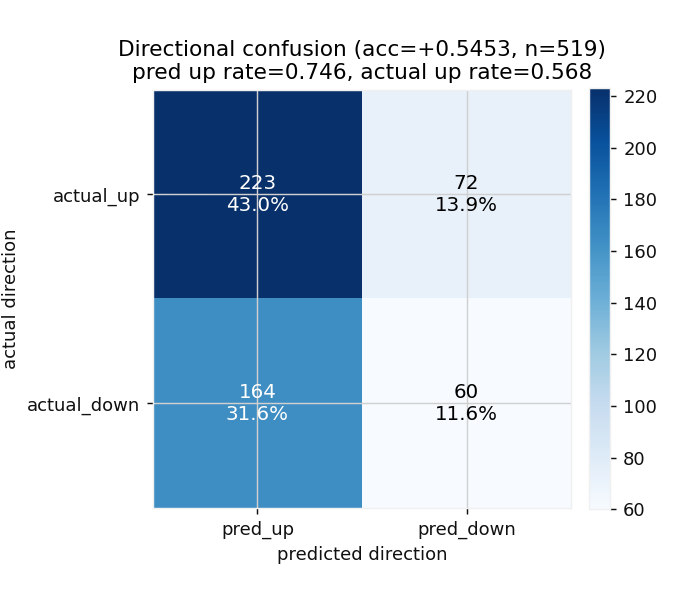

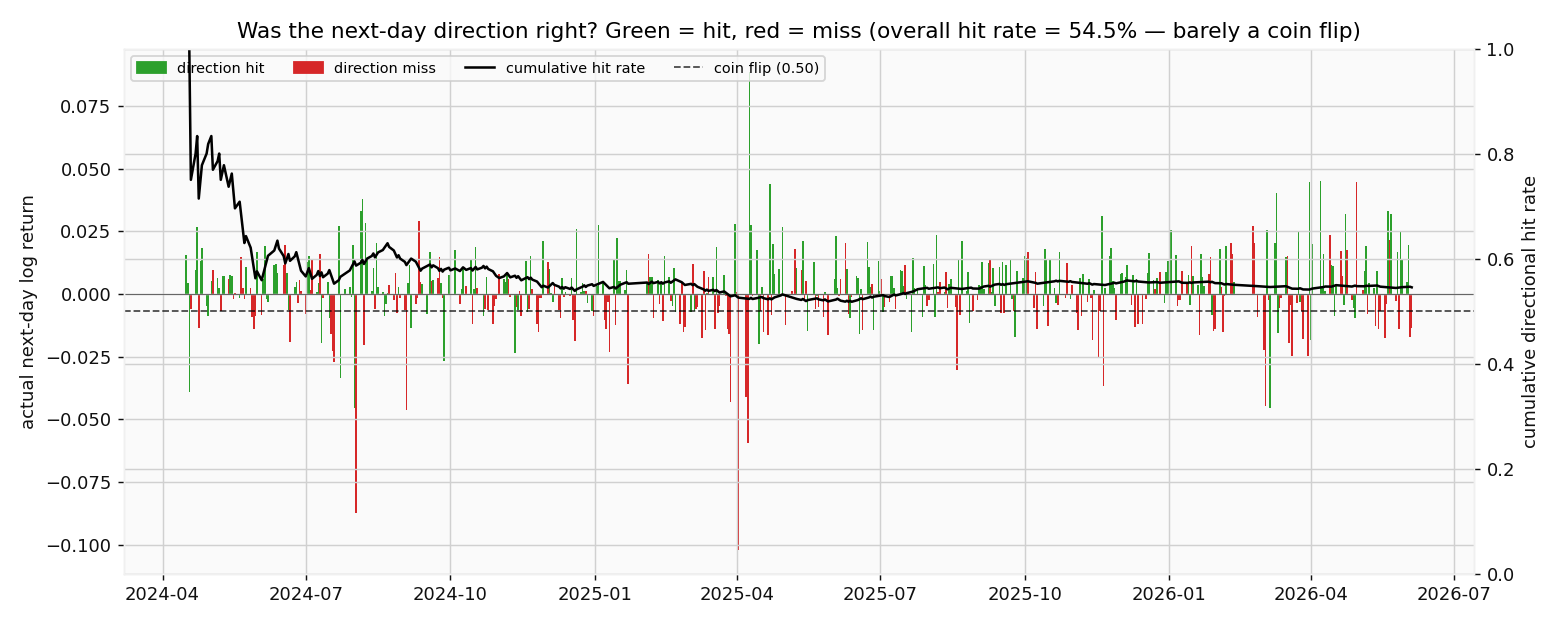

In [8]:
cm, cm_metrics = evaluate.direction_confusion(r["y_test"].values, r["y_pred"].values)
print("Binary up/down confusion matrix (rows = actual, cols = predicted):")
display(cm)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in cm_metrics.items()})

cm_png = plots.confusion_matrix(cm, cm_metrics)
ts_png = plots.actual_vs_predicted_timeseries(
    r["y_test"].index, r["y_test"].values, r["y_pred"].values
)
display(Image(cm_png)); display(Image(ts_png))

## Takeaway — ablation (no feature selection)

This variant feeds the LightGBM **all 36 features**, including the non-stationary
price-level family (MAs, EMAs, Bollinger bands, MACD) that the main pipeline's
temporal-consistency step drops. The picture is the same in spirit — a near-noise
target, R² ≈ 0, directional accuracy barely off a coin flip — but the headline numbers
come out **no better, and if anything slightly worse**, than the selected-feature run in
`run_pipeline.ipynb`. Compare the two notebooks' evaluation tables directly: keeping the
drifting price-level features adds variance without adding out-of-sample signal, which is
exactly the case for doing the temporal-consistency selection in the first place. The
result remains honest and un-inflated, reported per next-day prediction and always next
to its baseline.